In [22]:
from L1LLPJetTagger import delta_phi
import numpy as np
from L1LLPJetTagger.utils.utils import one_hot_encode_pdgid
from L1LLPJetTagger.utils.utils import pad_and_fill
from L1LLPJetTagger.utils.utils import known_ids
from L1LLPJetTagger.utils.config import config
from coffea.nanoevents import NanoEventsFactory, BaseSchema
import awkward as ak
import h5py
import os

In [23]:
import matplotlib.pyplot as plt

In [24]:
root_path = "/eos/user/r/russelld/TOOLLIP_TEST/CMSSW_15_1_0_pre4/src/jetTuple_extended_5.root"
tree_name = "outnano/Jets"

In [25]:
events = NanoEventsFactory.from_root(
        f"{root_path}:{tree_name}", schemaclass=BaseSchema
    ).events()

In [26]:
ak.to_list(events["jet_pfcand_id"][:5])

[[211, 211, 211, 211, 211, 22],
 [130, 211, 211, 22, 22],
 [211, 211, 211],
 [211, 211, 22],
 [211, 211]]

In [27]:
pad_and_fill(events["jet_pfcand_id"], 10)

<Array [[211, 211, 211, 211, ..., 0, 0, 0, 0], ...] type='814 * 10 * float64'>

In [28]:
jetDataF = h5py.File("/eos/user/r/russelld/TOOLLIP_TEST/CMSSW_15_1_0_pre4/src/L1LLPJetTagger/data/Signal_jet_data.h5", "r")

In [29]:
jetData = jetDataF["jet_data"][:]

In [30]:
jetData.shape

(188, 141)

In [31]:
physPt = ak.to_list(events["jet_pt_phys"])
pt = ak.to_list(events["jet_pt"])

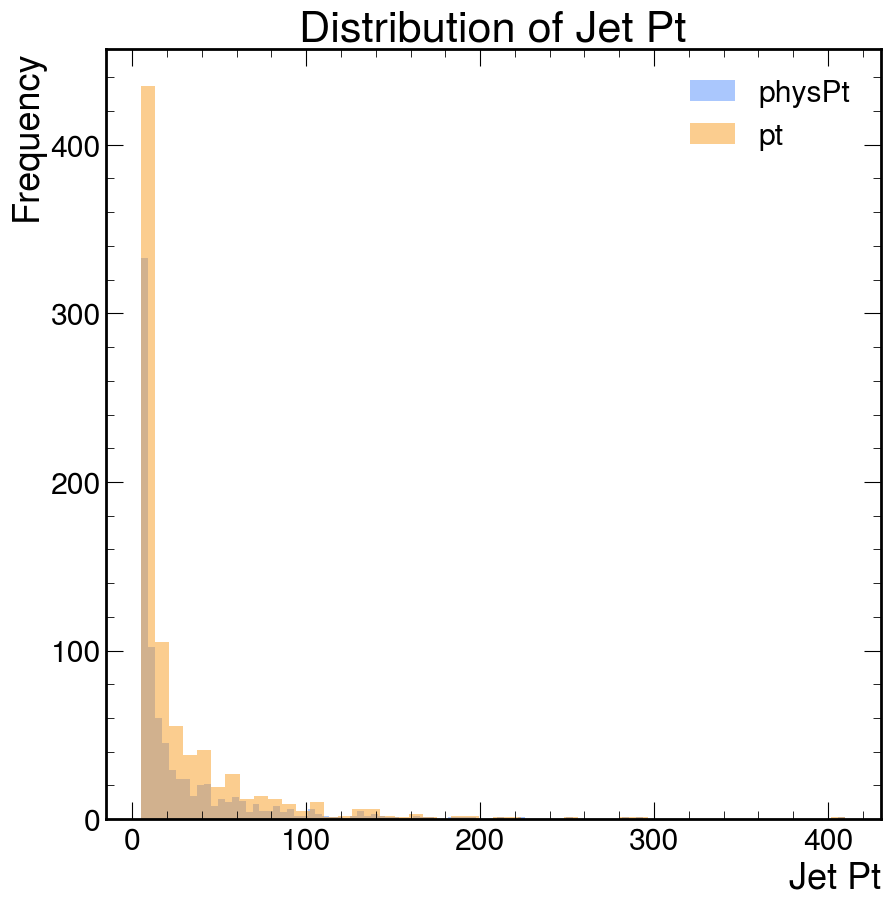

In [32]:
plt.hist(physPt, bins=101, alpha=0.5, label="physPt")
plt.hist(pt, bins=50, alpha=0.5, label="pt")
plt.xlabel("Jet Pt")
plt.ylabel("Frequency")
plt.title("Distribution of Jet Pt")
plt.legend()
plt.show()

In [33]:
jetData = ak.concatenate((events["jet_pt_phys"][...,None], events["jet_eta_phys"][..., None], \
                events["jet_phi_phys"][..., None], events["jet_mass"][..., None] ), axis=-1)

In [34]:
trainingData = h5py.File("/eos/user/r/russelld/TOOLLIP_TEST/CMSSW_15_1_0_pre4/src/L1LLPJetTagger/data/Signal_train.h5", "r")
trainingJetData = h5py.File("/eos/user/r/russelld/TOOLLIP_TEST/CMSSW_15_1_0_pre4/src/L1LLPJetTagger/data/Signal_trainJets.h5", "r")

In [35]:
train_array = trainingData["jet_constituents"][:]
trainJet_array = trainingJetData["train_jet_data"][:]

In [36]:
train_array.shape, trainJet_array.shape

((150, 141), (150, 4))

In [37]:
!pwd

/eos/home-r/russelld/TOOLLIP_TEST/CMSSW_15_1_0_pre4/src


In [38]:
from plotting.kinematics_plotter import kinematics

In [44]:
import importlib
import plotting.kinematics_plotter as km
importlib.reload(km)
from plotting.kinematics_plotter import kinematics

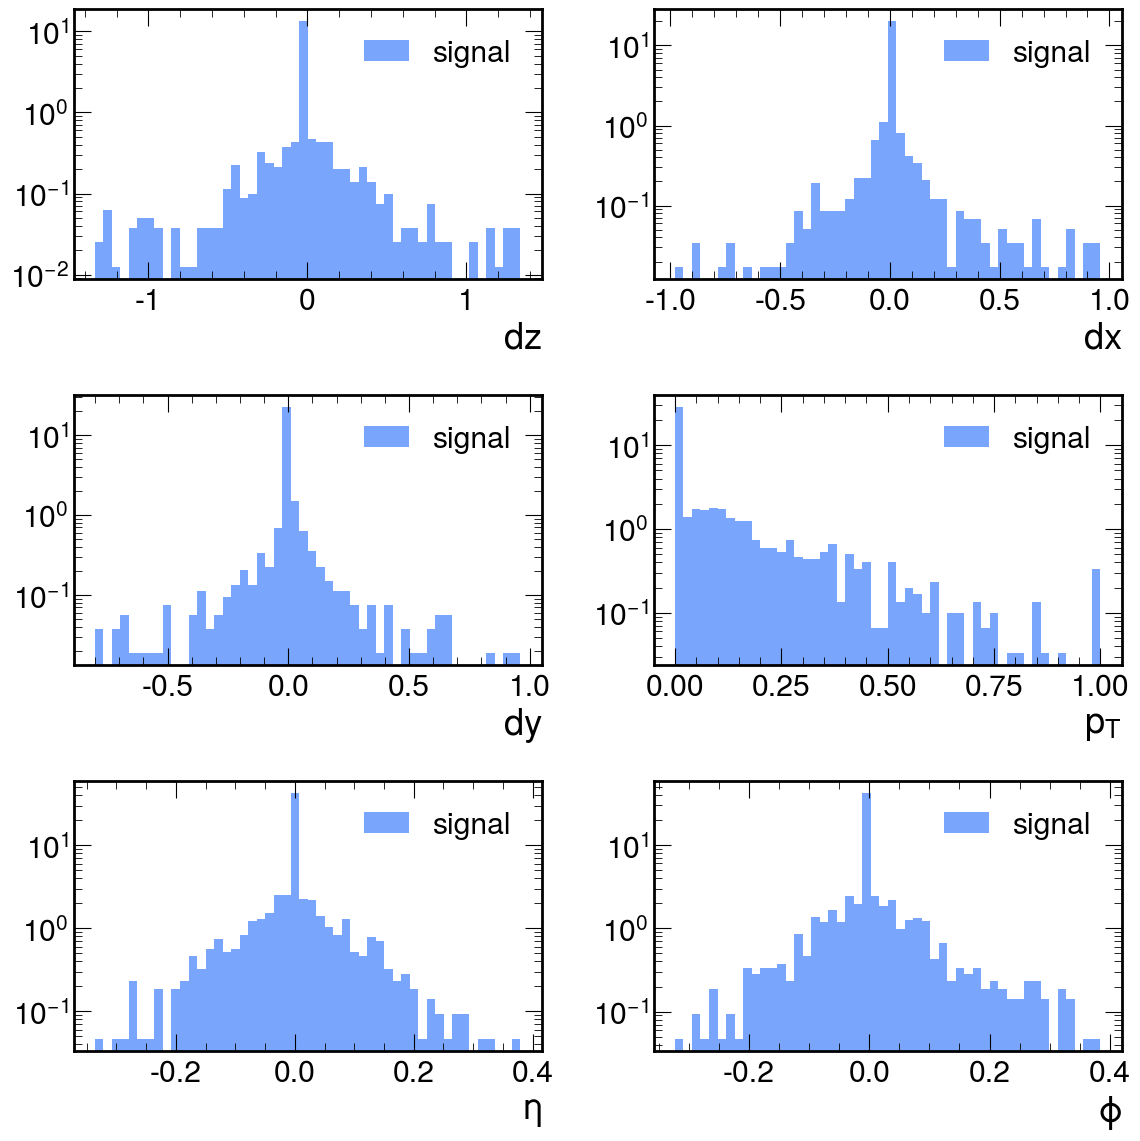

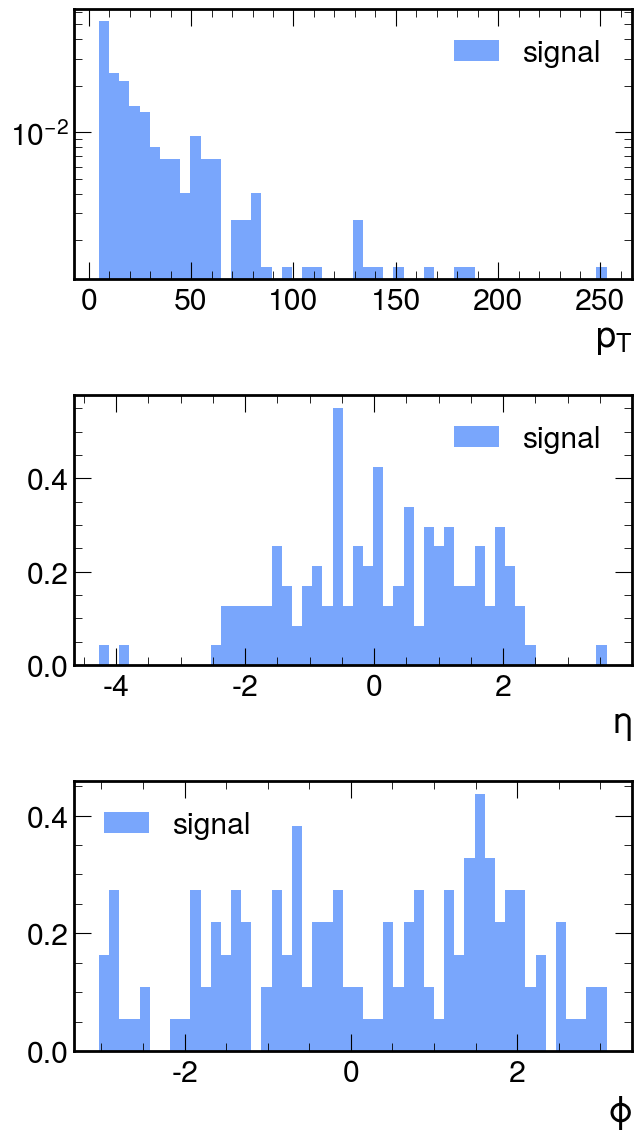

In [45]:
kinematics(train_array[:, :-1].reshape(len(train_array), 10, 14), trainJet_array, train_array[:, -1], "plotting", "test" )